In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             roc_curve)

# Load clean data
df = pd.read_csv("../data/myopia_model_ready.csv")

# Define features and target
X = df.drop('MYOPIC', axis=1)
y = df['MYOPIC']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("DATASET:")
print(f"Training set: {X_train.shape[0]} patients")
print(f"Testing set:  {X_test.shape[0]} patients")
print(f"Myopic in training: {y_train.sum()}")
print(f"Myopic in testing:  {y_test.sum()}")

# Train Naive Bayes
# Note: Naive Bayes does not need scaling
# It calculates probabilities from raw values
model = GaussianNB()
model.fit(X_train, y_train)
print("\nNaive Bayes trained successfully!")

# Class probabilities learned
print("\nCLASS PROBABILITIES LEARNED:")
print(f"P(Not Myopic): {model.class_prior_[0]:.4f} ({model.class_prior_[0]*100:.1f}%)")
print(f"P(Myopic):     {model.class_prior_[1]:.4f} ({model.class_prior_[1]*100:.1f}%)")

DATASET:
Training set: 494 patients
Testing set:  124 patients
Myopic in training: 65
Myopic in testing:  16

Naive Bayes trained successfully!

CLASS PROBABILITIES LEARNED:
P(Not Myopic): 0.8684 (86.8%)
P(Myopic):     0.1316 (13.2%)


NAIVE BAYES RESULTS:
Accuracy:  0.8629
ROC AUC:   0.7963

Classification Report:
              precision    recall  f1-score   support

  Not Myopic       0.90      0.94      0.92       108
      Myopic       0.45      0.31      0.37        16

    accuracy                           0.86       124
   macro avg       0.68      0.63      0.65       124
weighted avg       0.84      0.86      0.85       124



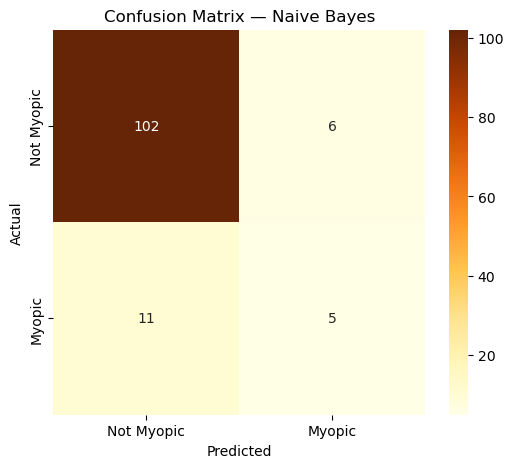

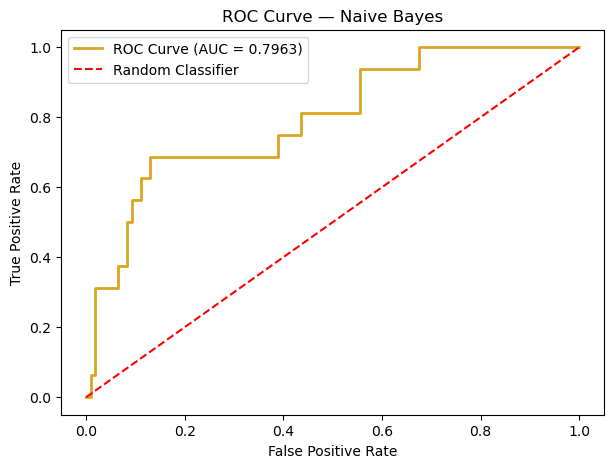


FEATURE MEAN VALUES LEARNED:
(What Naive Bayes thinks each group looks like)
      Feature  Not Myopic Mean  Myopic Mean  Difference
0         AGE            6.322        6.323       0.001
1      GENDER            0.480        0.554       0.074
2       SPHEQ            0.892        0.147      -0.745
3          AL           22.497       22.567       0.070
4         ACD            3.581        3.654       0.073
5          LT            3.545        3.515      -0.030
6         VCD           15.371       15.397       0.027
7     SPORTHR           12.191       10.385      -1.807
8      READHR            2.699        3.062       0.362
9      COMPHR            2.131        2.185       0.054
10    STUDYHR            1.557        1.292      -0.265
11       TVHR            8.753        8.400      -0.353
12  DIOPTERHR           25.783       25.831       0.048
13      MOMMY            0.492        0.677       0.185
14      DADMY            0.457        0.738       0.282

Results saved:
{'Model': 

In [2]:
# ============================================
# MAKE PREDICTIONS
# ============================================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ============================================
# EVALUATION METRICS
# ============================================
print("NAIVE BAYES RESULTS:")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Not Myopic', 'Myopic']))

# ============================================
# CONFUSION MATRIX
# ============================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['Not Myopic', 'Myopic'],
            yticklabels=['Not Myopic', 'Myopic'])
plt.title("Confusion Matrix — Naive Bayes")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# ============================================
# ROC CURVE
# ============================================
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='goldenrod',
         linewidth=2,
         label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='red',
         linestyle='--', label='Random Classifier')
plt.title("ROC Curve — Naive Bayes")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ============================================
# FEATURE PROBABILITIES
# ============================================
print("\nFEATURE MEAN VALUES LEARNED:")
print("(What Naive Bayes thinks each group looks like)")
feature_means = pd.DataFrame({
    'Feature': X.columns,
    'Not Myopic Mean': model.theta_[0],
    'Myopic Mean': model.theta_[1]
})
feature_means['Difference'] = (feature_means['Myopic Mean'] -
                                feature_means['Not Myopic Mean'])
print(feature_means.round(3))

# Save results
nb_results = {
    'Model': 'Naive Bayes',
    'Accuracy': round(accuracy_score(y_test, y_pred), 4),
    'ROC_AUC': round(roc_auc_score(y_test, y_prob), 4)
}
print("\nResults saved:")
print(nb_results)